In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [4]:
AC_stark_vals=[-0.3065898535663432]
AC_stark_vals_ef=[-2.206589853566343]
A_vals=[12.060132973240993]

## Simulaatio

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [6]:
def find_params(f_d,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = pulses.sim_3_part_pulses(f_d,delta,A,evolution,dim,f_rabi,t_ramp=10,U_f=1,drag=True)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.semilogy(AC_stark_vals, max_f_vals)
    plt.xlabel("ω_supp (GHz)")
    plt.ylabel("Suurin f-tason todennäköisyys")
    plt.show()
    
    index=np.argmin(max_f_vals)
    delta=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(delta,pi_pulse,[e_max,f_max],max_e_vals)

In [7]:
f_rabi=2*np.pi/(35)
params=find_params(qubit.frequency/3-0.33760153186766884, 12.623565214482177, evolution_eigenbasis,f_rabi,0,[-500,500],10)

m=10

vals = pulses.sim_3_part_pulses(qubit.frequency/3-0.33760153186766884,params[0],12.623565214482177,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=10,U_f=1,drag=True)

print("AC-stark siirtymä (GHz):", params[0])

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")

KeyboardInterrupt: 

In [ ]:
m=1
vals = pulses.sim_3_part_pulses(qubit.frequency/3-0.33760153186766884,f_ef/3+params[0],12.623565214482177,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=10,U_f=1,drag=False)

print("AC-stark siirtymä (GHz):", params[0])

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")

In [ ]:
m=1
vals = pulses.sim_3_part_pulses(qubit.frequency/3-0.33760153186766884,params[0],12.623565214482177,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=10,U_f=1,drag=True)

print("AC-stark siirtymä (GHz):", params[0])

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")

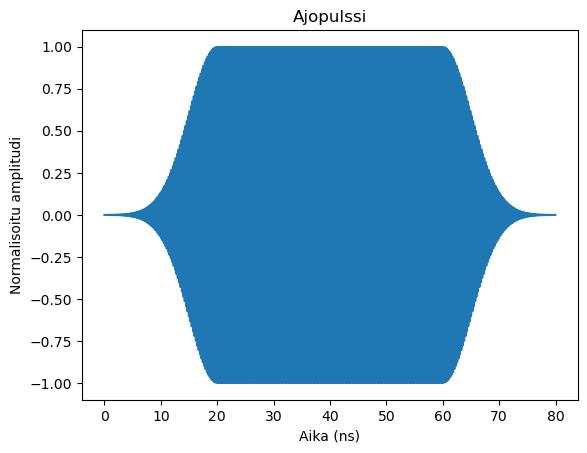

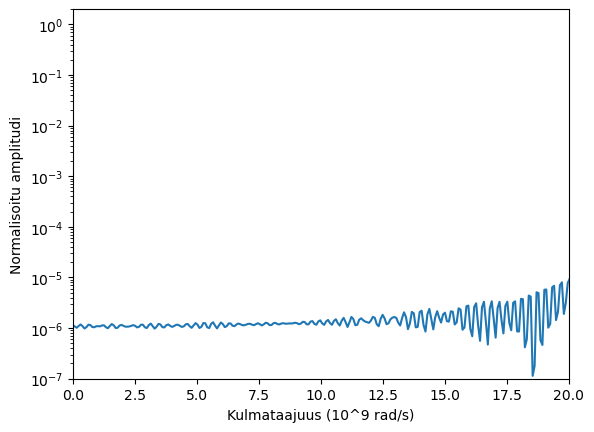

Amplitudi (GHz): 0.13079677028820533
E-tason suurin todennäköisyys: 0.99990860940185
F-tason suurin todennäköisyys: 1.1065723304172775e-07


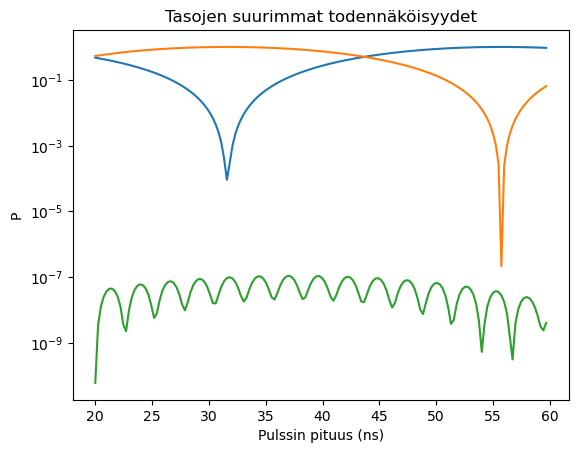

In [29]:
m=1

f_d=qubit.frequency/3
f_supp=f_ef/3
A=0.13079677028820533
f_rabi=2*np.pi/40

def f(x):  
    A_vals_a=np.array([np.float64(0.012744300694748212), np.float64(0.02012258004433928), np.float64(0.02750085939393035), np.float64(0.03487913874352142), np.float64(0.04225741809311249), np.float64(0.04963569744270356), np.float64(0.05701397679229463), np.float64(0.0643922561418857), np.float64(0.07177053549147677), np.float64(0.07914881484106782), np.float64(0.0865270941906589), np.float64(0.09390537354024998), np.float64(0.10128365288984104), np.float64(0.10866193223943212), np.float64(0.11604021158902321), np.float64(0.12341849093861425), np.float64(0.13079677028820533), np.float64(0.13817504963779637), np.float64(0.14555332898738746), np.float64(0.15293160833697855)])
    AC_stark_a=np.array([4e-05, 9e-05, 0.00017, 0.00027, 0.0004, 0.00055, 0.00073, 0.00093, 0.00116, 0.00141, 0.00169, 0.00199, 0.00231, 0.00266, 0.00301, 0.00344, 0.00384, 0.00431, 0.00475, 0.00531])

    closest_index = np.abs(A_vals_a - x*A).argmin()
    return f_d*3+AC_stark_a[closest_index]

vals = pulses.sim_3_part_pulses(f,f_supp,A,evolution_eigenbasis,dim,f_rabi/m,t_ramp=10,U_f=1,drag=True, verbose=True)

print("Amplitudi (GHz):", A)

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

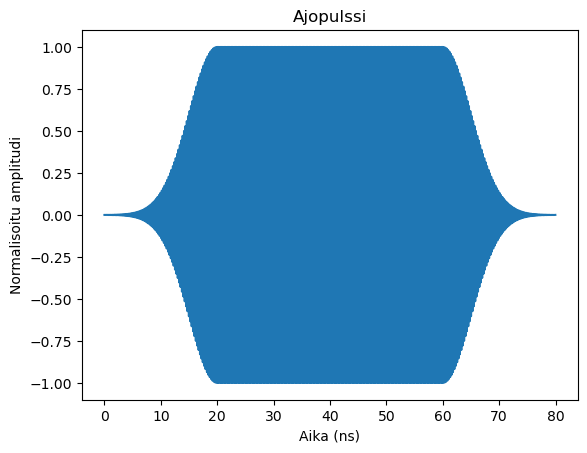

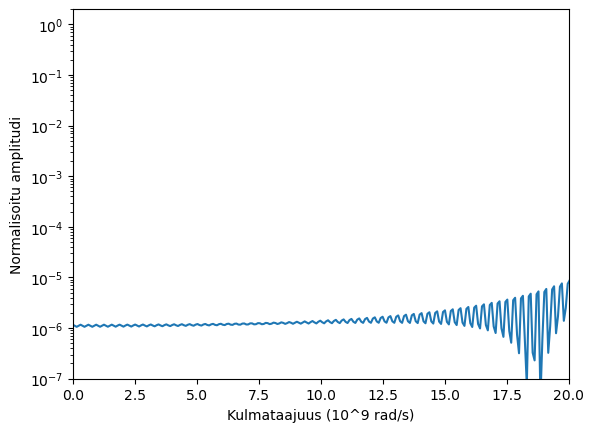

Amplitudi (GHz): 0.13079677028820533
E-tason suurin todennäköisyys: 0.9998866593695976
F-tason suurin todennäköisyys: 1.1302664128577139e-07


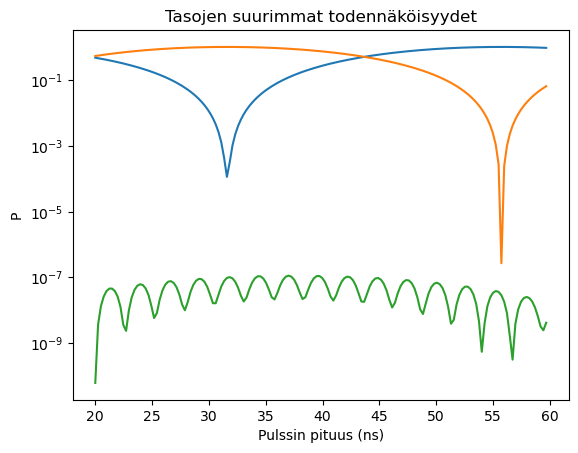

---------------------------------------------


In [28]:
AC_stark=0.0035
vals = pulses.sim_3_part_pulses(f_d*3+AC_stark,f_supp,A,evolution_eigenbasis,dim,f_rabi/m,t_ramp=10,U_f=1,drag=True, verbose=True)

print("Amplitudi (GHz):", A)

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")